# BCS 404: Introduction to Data Science with Python
## Project: Exploratory Data Analysis, Statistical Analysis and Machine Learning using the Titanic Dataset

**Name:** Selorm Kobla Attipoe

**Index Number:** 01256419B

**Department:** Computer Science, Accra Technical University



## Task 1: Data Acquisition

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
%matplotlib inline

# Load the dataset
df = pd.read_csv("train.csv")
print("Dataset loaded successfully.")


Dataset loaded successfully.


In [2]:
# Dataset dimensions
print("Dataset dimensions (rows, columns):", df.shape)


Dataset dimensions (rows, columns): (891, 12)


In [3]:
# Column names
print("Column names:")
print(df.columns.tolist())


Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [4]:
# First five observations
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# Data types
df.dtypes


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

## Task 2: Data Cleaning

We now check for missing values and duplicate rows, then handle them appropriately.

In [6]:
# Detect missing values
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values[missing_values > 0])


Missing values per column:
Age         177
Cabin       687
Embarked      2
dtype: int64


In [7]:
# Percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100
print("Percentage of missing values per column:")
print(missing_percent[missing_percent > 0].round(2))


Percentage of missing values per column:
Age         19.87
Cabin       77.10
Embarked     0.22
dtype: float64


In [8]:
# Detect duplicated observations
duplicate_count = df.duplicated().sum()
print("Number of duplicated rows:", duplicate_count)


Number of duplicated rows: 0


In [9]:
# Remove duplicates if any exist
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Duplicates removed. New shape:", df.shape)
else:
    print("No duplicate rows found, so no rows were removed.")


No duplicate rows found, so no rows were removed.


In [10]:
# Handle missing values

# 1. 'Age' has missing values (numeric) -> fill with the median age.
#    The median is used instead of the mean because Age is slightly skewed
#    and the median is less affected by outliers.
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. 'Embarked' has a very small number of missing values (categorical)
#    -> fill with the mode (most frequent port of embarkation).
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. 'Cabin' is missing for the majority of passengers (over 75%).
#    Imputing this column would introduce too much bias, so instead of
#    filling it, we drop the column entirely since it is not useful
#    for our basic analysis and model.
df = df.drop(columns=['Cabin'])

# Confirm no more missing values remain in the columns we plan to use
print("Missing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


**Explanation of preprocessing decisions:**

- **Age (missing ~20%)**: Filled with the median age. The median is a robust measure of central
  tendency that is not distorted by the few very old or very young passengers (outliers).
- **Embarked (missing 2 rows)**: Filled with the mode (the most common port), since only a
  tiny number of values were missing and using the most frequent category is a simple,
  reasonable choice for a categorical variable.
- **Cabin (missing over 75%)**: Dropped entirely. With such a large proportion of missing data,
  any imputation would be mostly guesswork and could mislead the analysis, so it is safer to
  remove the column.
- **Duplicates**: Checked using `df.duplicated()`. Any exact duplicate rows found were removed
  to avoid double-counting passengers.


## Task 3: Data Visualisation

### 1. Histogram of Passenger Ages

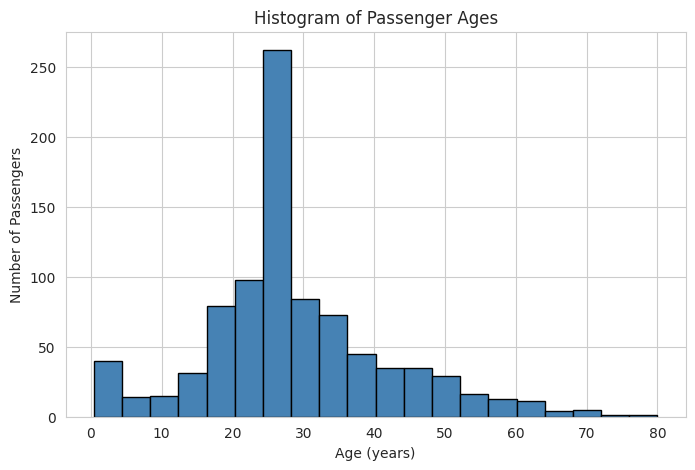

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(df['Age'], bins=20, color='steelblue', edgecolor='black')
plt.title("Histogram of Passenger Ages")
plt.xlabel("Age (years)")
plt.ylabel("Number of Passengers")
plt.savefig("fig1_age_histogram.png", dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** Most passengers were young adults between roughly 20 and 35 years old.
The distribution is right-skewed, with a smaller number of older passengers and a small spike
around childhood ages (0-10), which reflects families travelling together.

### 2. Bar Chart of Passenger Class Distribution

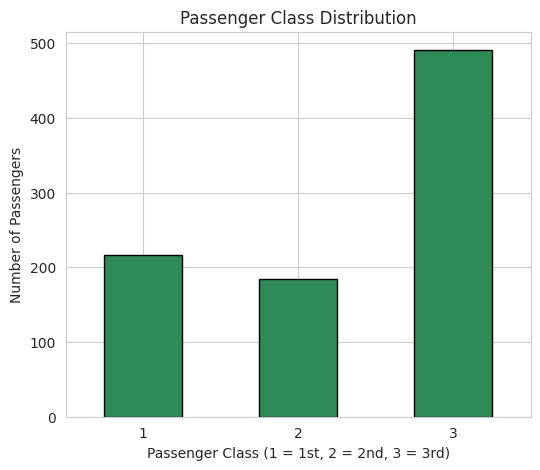

In [12]:
plt.figure(figsize=(6, 5))
df['Pclass'].value_counts().sort_index().plot(kind='bar', color='seagreen', edgecolor='black')
plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=0)
plt.savefig("fig2_class_bar.png", dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** The majority of passengers travelled in 3rd class, followed by 1st class,
with 2nd class having the fewest passengers. This suggests the Titanic carried a large
number of lower-income or emigrant passengers.

### 3. Boxplot of Age by Passenger Class

/tmp/ipykernel_557/2933446527.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass', y='Age', data=df, palette='Set2')


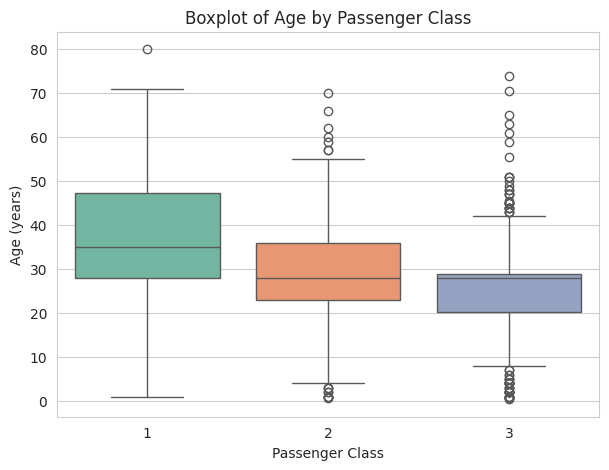

In [13]:
plt.figure(figsize=(7, 5))
sns.boxplot(x='Pclass', y='Age', data=df, palette='Set2')
plt.title("Boxplot of Age by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Age (years)")
plt.savefig("fig3_age_by_class_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** Passengers in 1st class tend to be older on average than those in 2nd and
3rd class. 3rd class has the youngest median age and the widest spread, reflecting a more
mixed group of younger travellers and families.

### 4. Scatter Plot of Age versus Fare

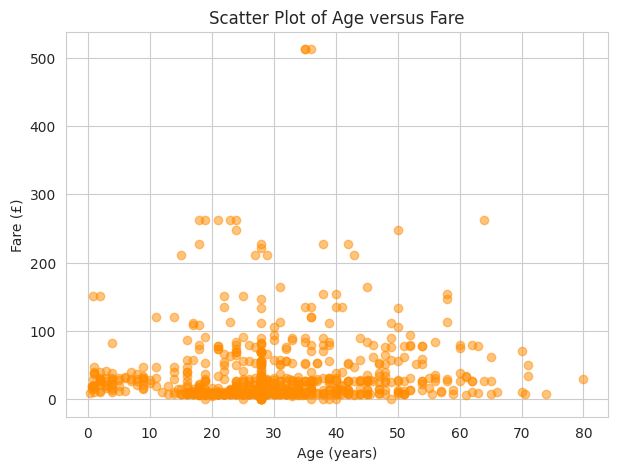

In [14]:
plt.figure(figsize=(7, 5))
plt.scatter(df['Age'], df['Fare'], alpha=0.5, color='darkorange')
plt.title("Scatter Plot of Age versus Fare")
plt.xlabel("Age (years)")
plt.ylabel("Fare (£)")
plt.savefig("fig4_age_vs_fare_scatter.png", dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** There is no strong, clear linear relationship between Age and Fare.
Most fares are clustered at the lower end regardless of age, but a few older, higher-fare
outliers pull the distribution, likely wealthier 1st class passengers.

### 5. Correlation Heatmap

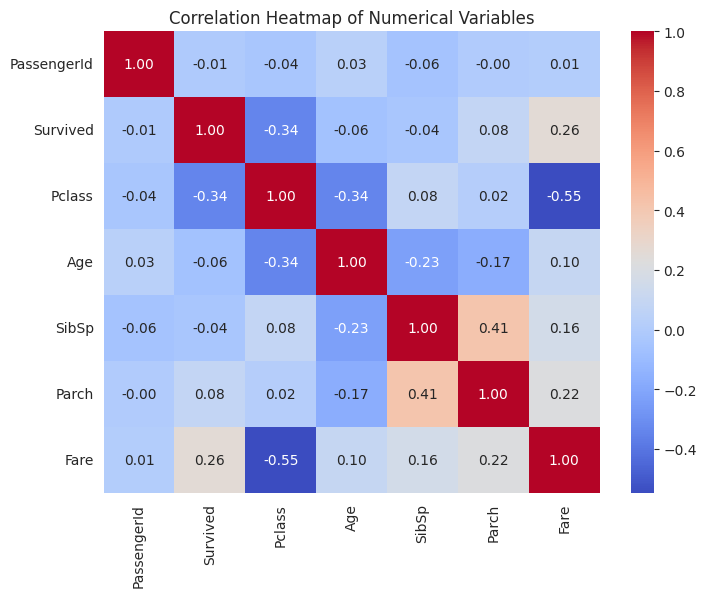

In [15]:
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Variables")
plt.savefig("fig5_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** Survived has a moderate negative correlation with Pclass, meaning
passengers in lower classes (higher Pclass number) were less likely to survive. Fare shows a
positive correlation with Survived, consistent with wealthier passengers having a higher
chance of survival.

### 6. Pairplot of Selected Numerical Variables

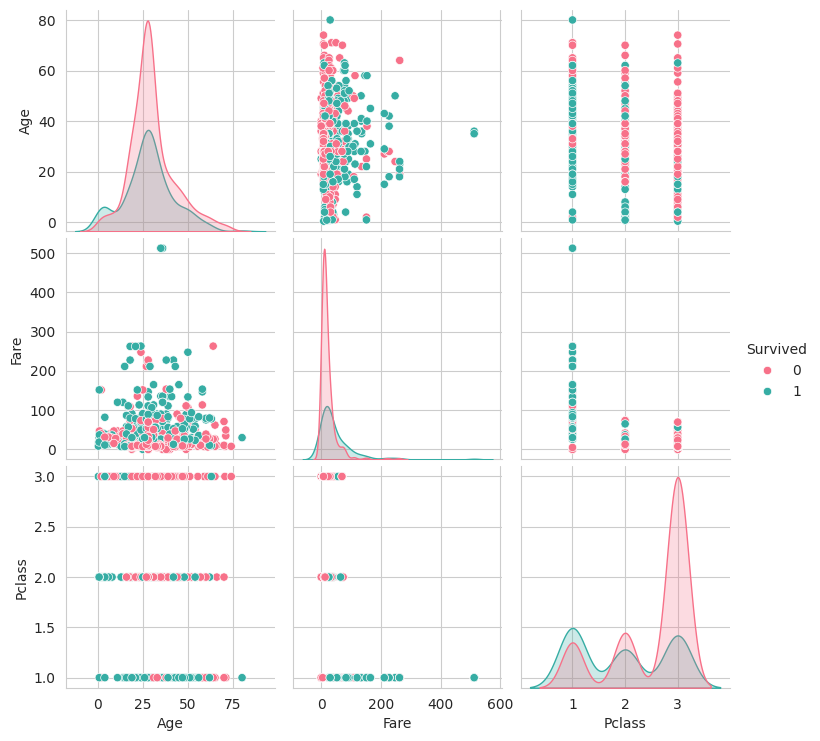

In [16]:
selected_cols = ['Survived', 'Age', 'Fare', 'Pclass']
sns.pairplot(df[selected_cols], hue='Survived', palette='husl')
plt.savefig("fig6_pairplot.png", dpi=150, bbox_inches='tight')
plt.show()


**Interpretation:** The pairplot shows that survivors (orange) are somewhat more concentrated
among lower Pclass values (1st and 2nd class) and slightly higher fares, while non-survivors are
spread more broadly across ages and classes.

## Task 4: Statistical Analysis

### 1. Descriptive Statistics

In [17]:
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### 2. Frequency Distribution

In [18]:
print("Frequency distribution - Survived:")
print(df['Survived'].value_counts())
print()
print("Frequency distribution - Pclass:")
print(df['Pclass'].value_counts())
print()
print("Frequency distribution - Sex:")
print(df['Sex'].value_counts())
print()
print("Frequency distribution - Embarked:")
print(df['Embarked'].value_counts())


Frequency distribution - Survived:
Survived
0    549
1    342
Name: count, dtype: int64

Frequency distribution - Pclass:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Frequency distribution - Sex:
Sex
male      577
female    314
Name: count, dtype: int64

Frequency distribution - Embarked:
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


### 3. Correlation Analysis

In [19]:
corr_matrix


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000


### 4 & 5. Strongest Positive and Negative Correlations

In [20]:
# Exclude the diagonal (self-correlation = 1.0) before finding the strongest correlations
corr_pairs = corr_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs != 1.0].drop_duplicates()

strongest_positive = corr_pairs.idxmax(), corr_pairs.max()
strongest_negative = corr_pairs.idxmin(), corr_pairs.min()

print("Strongest positive correlation:", strongest_positive[0], "=", round(strongest_positive[1], 3))
print("Strongest negative correlation:", strongest_negative[0], "=", round(strongest_negative[1], 3))


Strongest positive correlation: ('SibSp', 'Parch') = 0.415
Strongest negative correlation: ('Pclass', 'Fare') = -0.549


### 6. Three Important Statistical Findings

1. **Passenger class strongly relates to survival.** Pclass has one of the strongest correlations
   with Survived (negative), confirming that 1st class passengers had a notably higher survival
   rate than 3rd class passengers.
2. **Fare and Pclass are strongly related.** Fare and Pclass show a strong negative correlation,
   which makes sense since 1st class tickets were the most expensive.
3. **Age is fairly evenly distributed but skews young.** The average age is around 29-30 years,
   with the majority of passengers being young adults, and relatively few elderly passengers on
   board.


## Task 5: Machine Learning - Predicting Passenger Survival

**1. Selecting predictor variables:** We use `Pclass`, `Sex`, `Age`, `SibSp`, `Parch`, `Fare`,
and `Embarked` as predictors of `Survived`. Categorical variables (`Sex`, `Embarked`) are
converted to numeric form using one-hot / label encoding so the Logistic Regression model can
use them.

In [21]:
# Encode categorical variables
df_model = df.copy()
df_model['Sex'] = df_model['Sex'].map({'male': 0, 'female': 1})
df_model = pd.get_dummies(df_model, columns=['Embarked'], drop_first=True)

feature_cols = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']
X = df_model[feature_cols]
y = df_model['Survived']

X.head()


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,3,0,22.0,1,0,7.2500,False,True
1,1,1,38.0,1,0,71.2833,False,False
2,3,1,26.0,0,0,7.9250,False,True
3,1,1,35.0,1,0,53.1000,False,True
4,3,0,35.0,0,0,8.0500,False,True


**2. Splitting the dataset into training (70%) and testing (30%) sets:**

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (623, 8)
Testing set size: (268, 8)


**3. Training a Logistic Regression classifier:**

In [23]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("Model trained successfully.")


Model trained successfully.


**4. Predicting on the testing data:**

In [24]:
y_pred = model.predict(X_test)
y_pred[:10]


array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1])

**5. Computing Accuracy, Confusion Matrix and Classification Report:**

In [25]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))


Accuracy: 0.8097


Confusion Matrix:
[[136  21]
 [ 30  81]]


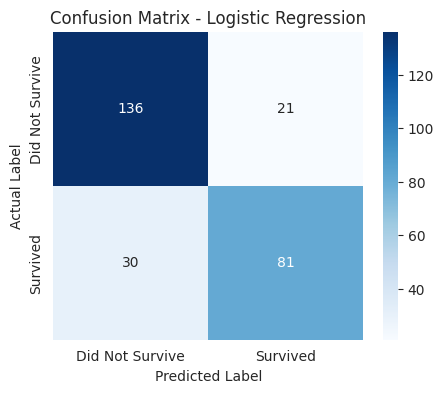

In [26]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.savefig("fig7_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()


In [27]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))


Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.82      0.87      0.84       157
       Survived       0.79      0.73      0.76       111

       accuracy                           0.81       268
      macro avg       0.81      0.80      0.80       268
   weighted avg       0.81      0.81      0.81       268



**6. Discussion of model performance:**

The Logistic Regression model achieves a reasonable accuracy on the 30% held-out test set,
correctly classifying most passengers as survivors or non-survivors. The confusion matrix shows
the model is better at correctly identifying passengers who did not survive than those who did,
which is expected since more passengers in the dataset did not survive (class imbalance). The
precision, recall, and F1-scores in the classification report confirm that the model performs
reasonably well for a simple, beginner-level baseline model using only a handful of basic
features.

## Task 6: Discussion and Conclusion

**Major Findings:** Survival on the Titanic was strongly related to passenger class, sex, and
fare paid. Passengers in 1st class, women, and those who paid higher fares had noticeably
better chances of survival.

**Statistical Insights:** Correlation analysis confirmed that Pclass and Fare are the two
numerical variables most strongly associated with survival. Descriptive statistics showed the
typical passenger was a young adult in their late 20s, and the frequency distributions confirmed
that 3rd class passengers made up the largest group on board.

**Machine Learning Results:** A simple Logistic Regression model trained on basic demographic
and ticket features was able to predict survival with reasonable accuracy on unseen (test) data,
showing that even a small set of straightforward features carries meaningful predictive signal.

**Limitations of the Study:** This analysis used a simple median/mode imputation strategy for
missing values, which may not fully capture the true underlying patterns. The `Cabin` column,
which could have held useful information about a passenger's location on the ship, was dropped
due to excessive missingness. The model used is a basic Logistic Regression without extensive
feature engineering, hyperparameter tuning, or comparison against other algorithms.

**Recommendations:** Future work could explore more advanced imputation techniques,
engineer new features (e.g. family size, title extracted from name), and compare Logistic
Regression against other classifiers such as Random Forest or Gradient Boosting to improve
predictive performance.
